# Music Data
## Pedro Henrique Kruta de Araújo Bispo, Erick Batista, João Vitor Costa, Igor de Melo




### O projeto Music Data tem como principal objetivo analisar músicas de rock lançadas nos anos 90 e 2010, com um foco especial nas características que interessam a guitarristas. A motivação é entender quais elementos estão associados às músicas mais populares da época e observar se houve mudanças relevantes nas composições, como aumento de velocidade, que podem influenciar a maneira de tocar e compor para esse estilo musical.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Leitura do dataset
df = pd.read_csv(r'/home/pedro/moises-chords-general/icd-database/MusicData/tracks_with_stems.csv',sep=';')

In [5]:
df.head()

,id,nome,artistas,album,release_date,duracao_ms,popularity,explicit,url,stem_path,BPM,Root_key
0,1EDPVGbyPKJPeGqATwXZvN,The Emptiness Machine,Linkin Park,From Zero,2024-11-15,190427,82,True,https://open.spotify.com/track/1EDPVGbyPKJPeGq...,guitar_stems/The_Emptiness_Machine_(Official_M...,93.0,D major
1,0COqiPhxzoWICwFCS4eZcp,Bring Me To Life,Evanescence,Fallen,2003-03-04,235893,85,False,https://open.spotify.com/track/0COqiPhxzoWICwF...,guitar_stems/Evanescence_-_Bring_Me_To_Life_(O...,95.0,E major
2,5Xak5fmy089t0FYmh3VJiY,Black,Pearl Jam,Ten,1991-08-27,342653,76,False,https://open.spotify.com/track/5Xak5fmy089t0FY...,guitar_stems/Pearl_Jam_-_Black_(Official_Audio...,77.0,A major
3,18lR4BzEs7e3qzc0KVkTpU,What I've Done,Linkin Park,Minutes to Midnight,2007-05-14,205226,81,False,https://open.spotify.com/track/18lR4BzEs7e3qzc...,guitar_stems/What_I've_Done_(Official_Music_Vi...,60.0,G minor
4,4nnJRbVecvQwqf3OQP4mja,These Days,Bon Jovi,These Days,1995-06-27,387826,59,False,https://open.spotify.com/track/4nnJRbVecvQwqf3...,guitar_stems/Bon_Jovi_-_These_Days.wav,66.0,E minor


### Normalizamos a data de lançamento apenas para os anos, pois possuiam casos onde a data era apenas os anos. Transformamos a duração para a escala de segundos para termos uma noção melhor dos dados

In [6]:
df['release_date'] = df['release_date'].apply(lambda x: str(x).split('-')[0])
df['duracao_ms'] = df['duracao_ms']/1000

### Transformamos a coluna das datas para valores numericos e filtramos apenas as musicas com data de lançamento <=2010, pois é o escopo principal do trabalho. 

In [7]:
# Garantir que 'release_date' seja numérico (se necessário)
df['release_date'] = pd.to_numeric(df['release_date'], errors='coerce')

# Substituir 'release_date' com valor maior que 2010 por None
df['release_date'] = df['release_date'].apply(lambda x: x if x <= 2010 else None)

# Remover as linhas onde 'release_date' é None
df = df.dropna(subset=['release_date'])

### Verificamos os outliers para a duração

{'whiskers': [<matplotlib.lines.Line2D at 0x74373330c510>,
 'caps': [<matplotlib.lines.Line2D at 0x74373330d990>,
 'boxes': [<matplotlib.lines.Line2D at 0x7437332e65d0>],
 'medians': [<matplotlib.lines.Line2D at 0x74373330ed10>],
 'fliers': [<matplotlib.lines.Line2D at 0x74373330f810>],
 'means': []}

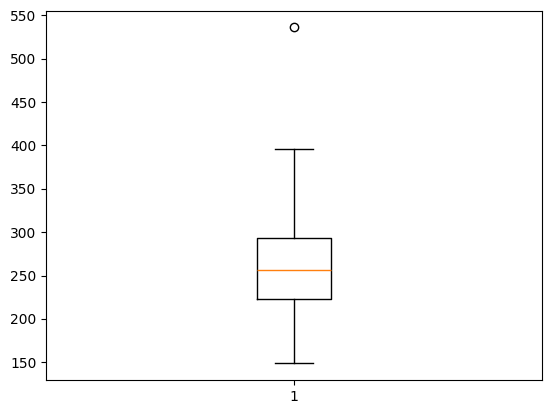

In [8]:
plt.boxplot(df['duracao_ms'])

### Remoção dos outliers

In [9]:
import pandas as pd

# Calcular os quartis (Q1 e Q3)
Q1 = df['duracao_ms'].quantile(0.25)
Q3 = df['duracao_ms'].quantile(0.75)

# Calcular o IQR
IQR = Q3 - Q1

# Definir limites inferior e superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar o DataFrame para remover os outliers
df = df[(df['duracao_ms'] >= limite_inferior) & (df['duracao_ms'] <= limite_superior)]

### Será que as músicas ficaram com uma duração menor ao longo dos anos?
### Primeiro vamos dividir nosso dataset entre as colunas de dados que possuimos e a coluna que queremos prever

In [10]:
df_group = df[['release_date', 'duracao_ms']]
df_group = df_group.sort_values(by='release_date')
X = df_group.iloc[:,1].values.reshape(-1,1)
y = df_group.iloc[:,0].values

### Plot dos dados após limpeza

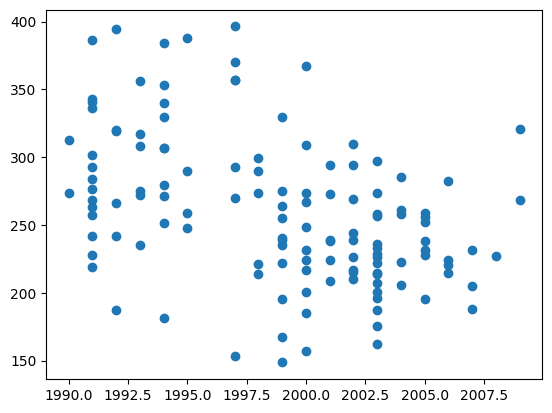

In [11]:
plt.scatter(y,X)

### Divisão do dataset entre treino e teste para podermos treinar nossa regressão linear

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

### Treinamento

In [13]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(f"Erro Quadrático Médio: {mse}")


Erro Quadrático Médio: 18.20152407370555


### Resultado da regressão nos dados de treino

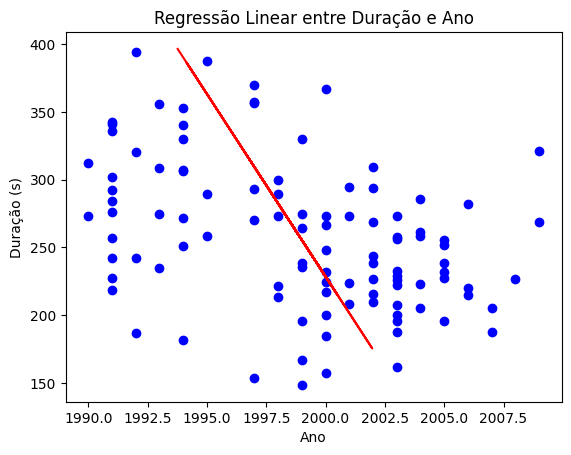

In [14]:
plt.scatter(y_train,X_train, color='blue')
plt.plot(y_pred,X_test, color='red')
plt.xlabel('Ano')
plt.ylabel('Duração (s)')
plt.title('Regressão Linear entre Duração e Ano')
plt.show()

### Resultados da regressão nos dados de teste

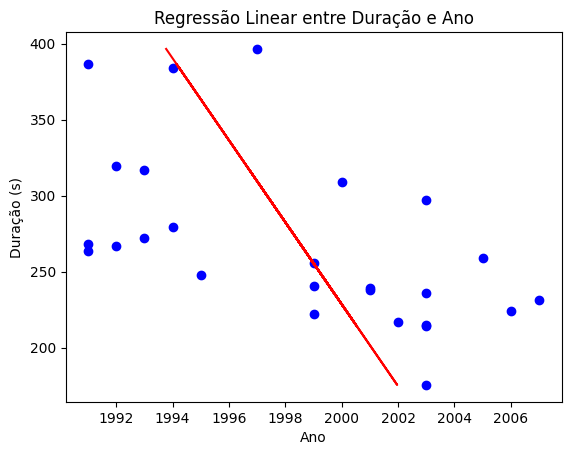

In [15]:
plt.scatter(y_test,X_test, color='blue')
plt.plot(y_pred,X_test, color='red')
plt.xlabel('Ano')
plt.ylabel('Duração (s)')
plt.title('Regressão Linear entre Duração e Ano')
plt.show()

### Podemos perceber claramente uma diminuição na duração das músicas ao decorrer dos anos, mesmo tendo um conjunto de dados pequeno e em um curto periodo de tempo, temos uma diminuição significativa. Devemos considerar também que estamos expecificando apenas para o rock, que normalmente custumam ser músicas mais longas, comparado a outros gêneros musicais e mesmo assim tivemos uma diminuição drástica

## Será que conseguimos extrair quais caracteristicas tornam uma música mais popular?

### Vamos analizar a correlação entre explicit, bpm e duração com sua popularidade

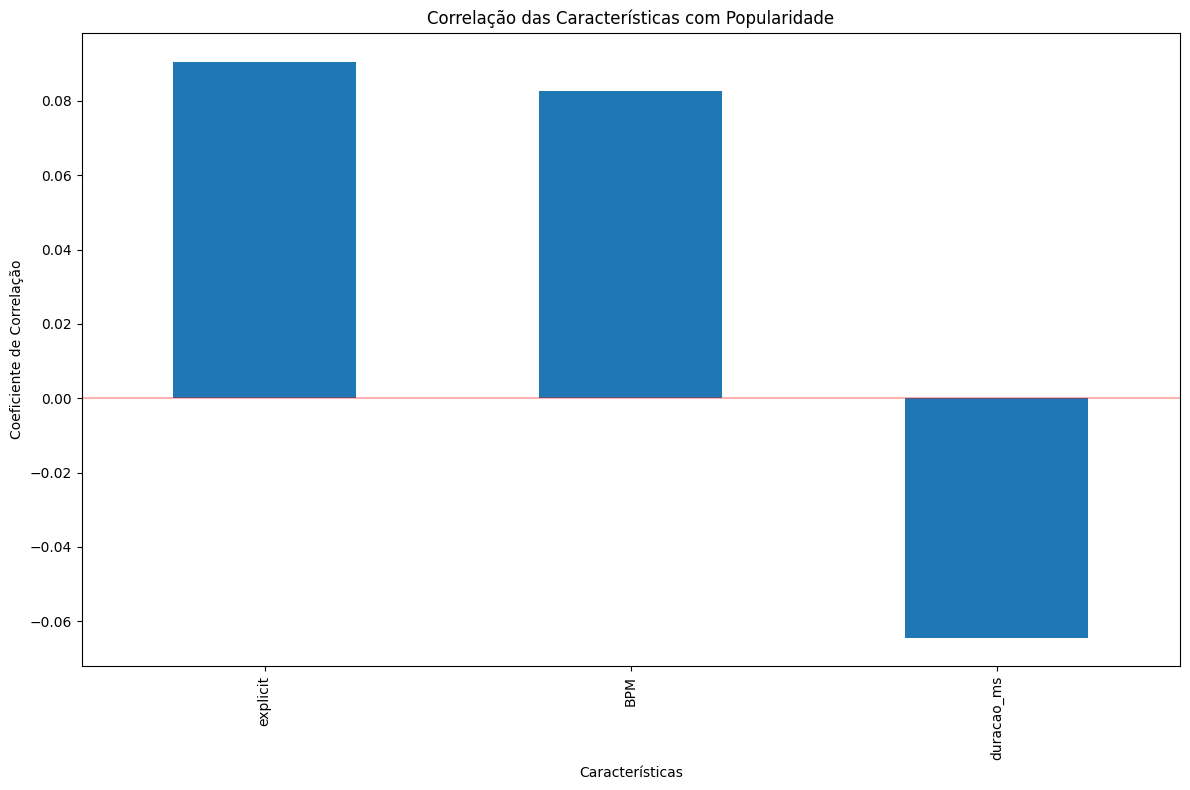

In [134]:
# Correlação de todas as características com a popularidade
df_corr = df.drop(columns=['id','nome','artistas','album','stem_path','url','Root_key','release_date'])
correlacao_popularidade = df_corr.corr()['popularity'].sort_values(ascending=False)

# Plotar como gráfico de barras
plt.figure(figsize=(12, 8))
correlacao_popularidade.drop('popularity').plot(kind='bar')
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.title('Correlação das Características com Popularidade')
plt.xlabel('Características')
plt.ylabel('Coeficiente de Correlação')
plt.tight_layout()
plt.show()

## Vamos extrair mais informações sobre os áudios para podermos fazer uma análise relacionada a caracteristicas do áudio

In [135]:
import librosa
import pandas as pd
import numpy as np
import os

# Funções para extrair características
def extract_features(audio_path):
    y, sr = librosa.load(audio_path, sr=None)
    
    # Energia 
    energia = np.mean(librosa.feature.rms(y=y)[0])
    
    # Acousticness - estimativa baseada no contraste espectral
    # Valores mais baixos de contraste espectral sugerem música mais acústica
    spec_contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr))
    acousticness = 1.0 - (spec_contrast / 50.0)  
    
    # Danceability - aproximação baseada na regularidade rítmica
    # Podemos usar a força da batida e regularidade dos onsets
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    tempo, _ = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr)
    beats = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr)[1]
    beats_strength = np.mean(onset_env[beats]) if len(beats) > 0 else 0
    beat_regularities = np.diff(beats) if len(beats) > 1 else np.array([0])
    beat_regularity = 1.0 - np.std(beat_regularities) / np.mean(beat_regularities) if len(beat_regularities) > 0 and np.mean(beat_regularities) > 0 else 0
    danceability = (beats_strength * beat_regularity) / 5.0  
    
    # Valência emocional - aproximação baseada na tonalidade e harmonia
    # Músicas em tom maior tendem a soar mais "felizes"
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    major_mask = np.array([1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1])  # Padrão de escala maior
    minor_mask = np.array([1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0])  # Padrão de escala menor
    
    major_correlation = np.zeros(12)
    minor_correlation = np.zeros(12)
    
    for i in range(12):
        # Rotacionar a máscara para cada possível tonalidade
        rolled_major = np.roll(major_mask, i)
        rolled_minor = np.roll(minor_mask, i)
        
        # Calcular correlação com o padrão de acordes da música
        major_correlation[i] = np.sum(chroma.mean(axis=1) * rolled_major)
        minor_correlation[i] = np.sum(chroma.mean(axis=1) * rolled_minor)
    
    # Se a correlação maior for com uma escala maior, tende a ser mais "feliz"
    is_major = np.max(major_correlation) > np.max(minor_correlation)
    consonance = np.max([np.max(major_correlation), np.max(minor_correlation)])
    
    valence = (0.7 if is_major else 0.3) * consonance
    
    return {
        'energia': float(energia),
        'acousticness': float(acousticness),
        'danceability': float(danceability),
        'valence': float(valence)
    }

features = []
for index, row in df.iterrows():
    print(f"Processando música {index+1}/{len(df)}: {row['nome']}")
    audio_path = row['stem_path']  
    
    try:
        song_features = extract_features(audio_path)
        song_features['id'] = row['id']
        features.append(song_features)
    except Exception as e:
        print(f"Erro ao processar {row['nome']}: {e}")

features_df = pd.DataFrame(features)

result_df = df.merge(features_df, on='id', how='left')

result_df.to_csv("dataset_com_features.csv", sep=";", index=False)

Processando música 2/130: Bring Me To Life


Processando música 3/130: Black
Processando música 4/130: What I've Done
Processando música 5/130: These Days
Processando música 6/130: Hero (feat. Josey Scott)
Processando música 7/130: Yellow
Processando música 9/130: How You Remind Me
Processando música 11/130: Dani California
Processando música 12/130: Wherever You Will Go
Processando música 14/130: WONDERWaLL - Remastered
Erro ao processar WONDERWaLL - Remastered: Invalid file: nan
Processando música 15/130: Never Gonna Be Alone
Processando música 16/130: Californication
Processando música 17/130: In the End
Processando música 19/130: I Miss You
Processando música 20/130: Save Me
Processando música 21/130: Livin' On A Prayer
Processando música 22/130: Learn to Fly
Erro ao processar Learn to Fly: Invalid file: nan
Processando música 24/130: Even Flow
Processando música 25/130: Knockin' On Heaven's Door
Processando música 26/130: Angels Or Devils
Processando música 27/130: Everything
Processando música 29/130: 21 Guns
Processando mú

In [136]:
result_df.head()

,id,nome,artistas,album,release_date,duracao_ms,popularity,explicit,url,stem_path,BPM,Root_key,energia,acousticness,danceability,valence
0,0COqiPhxzoWICwFCS4eZcp,Bring Me To Life,Evanescence,Fallen,2003.0,235.893,85,False,https://open.spotify.com/track/0COqiPhxzoWICwF...,guitar_stems/Evanescence_-_Bring_Me_To_Life_(O...,95.0,E major,0.032536,0.653776,0.690045,1.180762
1,5Xak5fmy089t0FYmh3VJiY,Black,Pearl Jam,Ten,1991.0,342.653,76,False,https://open.spotify.com/track/5Xak5fmy089t0FY...,guitar_stems/Pearl_Jam_-_Black_(Official_Audio...,77.0,A major,0.038471,0.600093,0.341169,0.866028
2,18lR4BzEs7e3qzc0KVkTpU,What I've Done,Linkin Park,Minutes to Midnight,2007.0,205.226,81,False,https://open.spotify.com/track/18lR4BzEs7e3qzc...,guitar_stems/What_I've_Done_(Official_Music_Vi...,60.0,G minor,0.061674,0.620906,0.293361,1.084744
3,4nnJRbVecvQwqf3OQP4mja,These Days,Bon Jovi,These Days,1995.0,387.826,59,False,https://open.spotify.com/track/4nnJRbVecvQwqf3...,guitar_stems/Bon_Jovi_-_These_Days.wav,66.0,E minor,0.073945,0.563075,0.351270,0.950748
4,779ooI3rBd0CLqCiiJmtVo,Hero (feat. Josey Scott),"Chad Kroeger, Josey Scott",Hero (feat. Josey Scott),2003.0,200.480,68,False,https://open.spotify.com/track/779ooI3rBd0CLqC...,guitar_stems/Hero_(feat._Josey_Scott).wav,75.0,E major,0.046119,0.648682,0.221070,1.221028


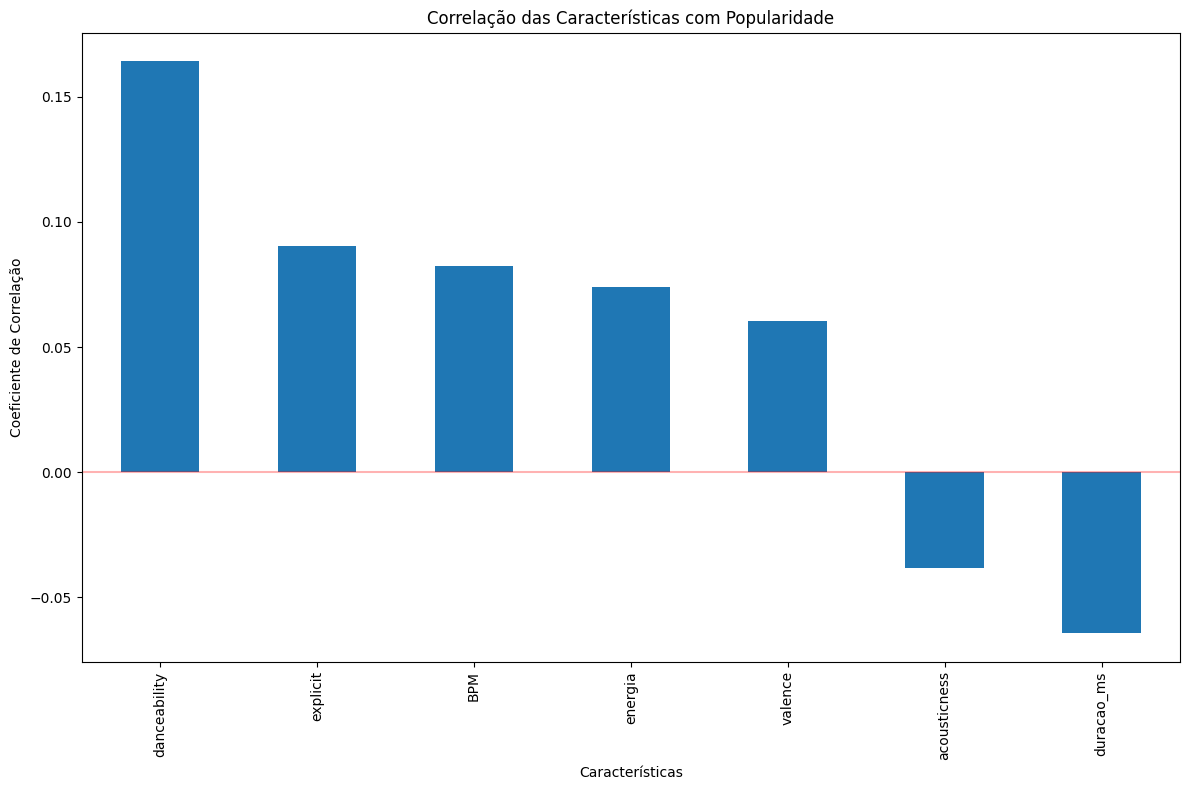

In [137]:
df_corr = result_df.drop(columns=['id','nome','artistas','album','stem_path','url','Root_key','release_date'])
correlacao_popularidade = df_corr.corr()['popularity'].sort_values(ascending=False)

plt.figure(figsize=(12, 8))
correlacao_popularidade.drop('popularity').plot(kind='bar')
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.title('Correlação das Características com Popularidade')
plt.xlabel('Características')
plt.ylabel('Coeficiente de Correlação')
plt.tight_layout()
plt.show()

## Após essa análise, vemos que a dançabilidade de uma música faz com que ela fique mais popular e temos também uma relação inversamente proporcional entre a duração e a popularidade, ou seja, quanto menor a música, mais popular ela é

## Quais são os artistas mais populares? 

In [50]:
df_artistas = pd.read_csv(r'/home/pedro/moises-chords-general/icd-database/MusicData/dataset_com_features.csv',sep=';')

In [51]:
df2 = df_artistas.copy()

In [38]:
df_artistas.head()

,id,nome,artistas,album,release_date,duracao_ms,popularity,explicit,url,stem_path,BPM,Root_key,energia,acousticness,danceability,valence
0,0COqiPhxzoWICwFCS4eZcp,Bring Me To Life,Evanescence,Fallen,2003.0,235.893,85,False,https://open.spotify.com/track/0COqiPhxzoWICwF...,guitar_stems/Evanescence_-_Bring_Me_To_Life_(O...,95.0,E major,0.032536,0.653776,0.690045,1.180762
1,5Xak5fmy089t0FYmh3VJiY,Black,Pearl Jam,Ten,1991.0,342.653,76,False,https://open.spotify.com/track/5Xak5fmy089t0FY...,guitar_stems/Pearl_Jam_-_Black_(Official_Audio...,77.0,A major,0.038471,0.600093,0.341169,0.866028
2,18lR4BzEs7e3qzc0KVkTpU,What I've Done,Linkin Park,Minutes to Midnight,2007.0,205.226,81,False,https://open.spotify.com/track/18lR4BzEs7e3qzc...,guitar_stems/What_I've_Done_(Official_Music_Vi...,60.0,G minor,0.061674,0.620906,0.293361,1.084744
3,4nnJRbVecvQwqf3OQP4mja,These Days,Bon Jovi,These Days,1995.0,387.826,59,False,https://open.spotify.com/track/4nnJRbVecvQwqf3...,guitar_stems/Bon_Jovi_-_These_Days.wav,66.0,E minor,0.073945,0.563075,0.351270,0.950748
4,779ooI3rBd0CLqCiiJmtVo,Hero (feat. Josey Scott),"Chad Kroeger, Josey Scott",Hero (feat. Josey Scott),2003.0,200.480,68,False,https://open.spotify.com/track/779ooI3rBd0CLqC...,guitar_stems/Hero_(feat._Josey_Scott).wav,75.0,E major,0.046119,0.648682,0.221070,1.221028


In [39]:
df_artistas = df_artistas.groupby('artistas')['popularity'].mean().sort_values(ascending=False)

/tmp/ipykernel_1525/1901855868.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df_artistas.index, y=df_artistas.values, palette='coolwarm')


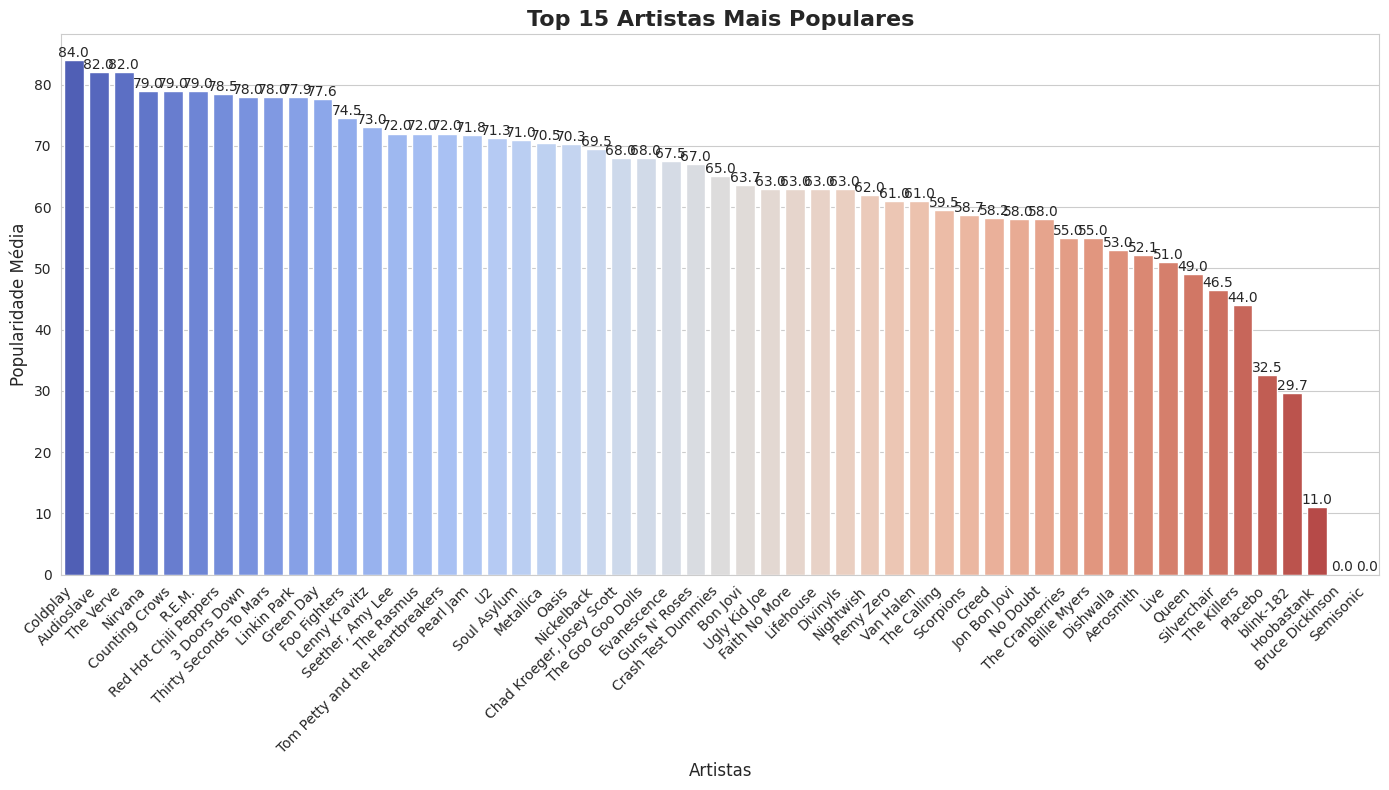

In [40]:
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

ax = sns.barplot(x=df_artistas.index, y=df_artistas.values, palette='coolwarm')

plt.title('Top 15 Artistas Mais Populares', fontsize=16, fontweight='bold')
plt.xlabel('Artistas', fontsize=12)
plt.ylabel('Popularidade Média', fontsize=12)

plt.xticks(rotation=45, ha='right')

for i, v in enumerate(df_artistas.values):
    ax.text(i, v + 0.5, f"{v:.1f}", ha='center')

plt.tight_layout()
plt.show()

## Em resumo, este estudo mostrou que músicas populares de rock nos anos 90-2010 tendem a ter boa dançabilidade, letras explícitas e BPM maiores, características que compositores e guitarristas podem levar em consideração ao criar novas músicas, percebemos que a dançabilidade é um dos fatores que mais impactam na popularidade da música (dentre os estudados). Também foi identificado um declínio gradual da duração das músicas ao longo dos anos, mesmo dentro de um intervalo curto de tempo.

Next Steps:
- Aumentar conjunto de dados
- Ampliar o estudo para outras décadas do rock.
- Aplicar técnicas de agrupamento (clustering) para identificar diferentes estilos dentro do rock da época.
- Extrair mais características dos áudio 
- Melhorar a seleção das músicas

### id (string): ID da música no Spotify (utilizado no url). 
Ex: 6MYzjR2rH0hfz91FsaR1ox

### nome (string): Nome da música. 
Ex: So Strange (feat. Cuco)

### artistas (string): Nome da banda/artista da música, incluindo participações. 
Ex: Polyphia, Cuco

### album (string): Nome do álbum da música. 
Ex: New Levels New Devils

### release_date (string): Data de lançamento da música. Pode ter apenas o ano ou a data específica no formato “ano-mês-dia”. 
Ex: 2018-10-12

### duracao_ms (int): Duração da música em milissegundos.
Ex: 240005

### popularity (int): Medição da popularidade da música no Spotify. Um valor de 0 a 100, sendo 100 a mais popular. Baseado na quantidade de vezes que a música foi tocada e o quão recente foram tocadas. 
Ex: 46

### explicit (bool): Valor booleano para se a música tem letras explícitas (True se tem e False se não tem ou é desconhecido)
Ex: False

### url (string): URL (link) da música no Spotify
Ex: https://open.spotify.com/track/6MYzjR2rH0hfz91FsaR1ox

### stem_path (string): Caminho do áudio de guitarra separado nos arquivos
Ex: ./stem - guitarra/Polyphia | So Strange (feat. Cuco).mp3

### bpm (float): Batidas por minuto, utilizado para medir o andamento musical
Ex: 120

### tom (string): Tonalidade da música em escala
Ex: C# Major

### danceability (int): Reflete o quão adequada a música é para dançar, baseada em elementos como ritmo, regularidade e força da batida.

### energia (int): Representa a intensidade e atividade percebida na música.

### valência emocional (int): Indica o quão positiva ou feliz a música soa.
Ex: 1.18

### acousticness (int): Mede a probabilidade da música ser acústica (vs. eletrônica).